In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# updated src file changes are loaded
%load_ext autoreload
%autoreload 2

sys.path.append(os.path.abspath(".."))

In [2]:
washout_df_3 = pd.read_csv('C:/Users/jacob/water_current_MA/data/dual_generalization/aftereffects_3.0_df.csv')
washout_df_3

,block_num,trial_in_block,target_id,mean_dev,baseline_ci_threshold_high,baseline_ci_aftereffect,training_ci_low,training_ci_high,inside_training_ci
0,1,1,L60,37.21,2.33,True,28.11,57.22,True
1,1,1,L30,18.02,2.62,True,18.96,40.07,False
2,1,1,R30,15.94,2.33,True,10.06,32.03,True
3,1,1,R60,6.40,2.67,True,-0.94,16.75,True
4,1,2,L60,12.17,2.33,True,28.11,57.22,False
...,...,...,...,...,...,...,...,...,...
167,-1,2,R60,2.36,2.67,False,-0.94,16.75,True
168,-1,3,L60,1.84,2.33,False,28.11,57.22,False
169,-1,3,L30,2.10,2.62,False,18.96,40.07,False
170,-1,3,R30,-0.08,2.33,False,10.06,32.03,False


In [23]:
target_order = pd.CategoricalDtype(categories=['L60','L30','R30','R60'], ordered=True)
washout_df_3['target_id'] = washout_df_3['target_id'].astype(target_order)

block_order = pd.CategoricalDtype(categories=[1, 2, 3, 4, 5, -1], ordered=True)
washout_df_3['block_num'] = washout_df_3['block_num'].astype(block_order)


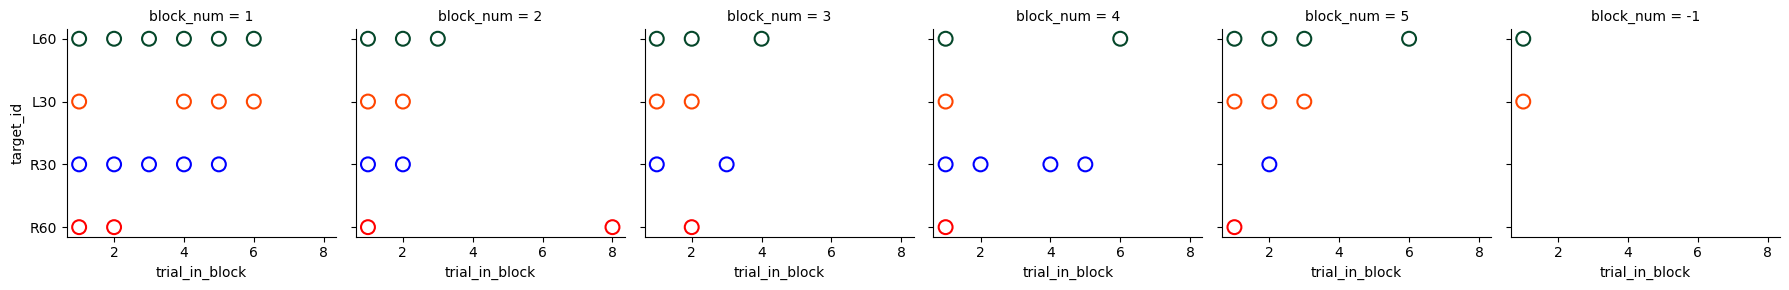

In [37]:
import seaborn as sns

_colors = sns.color_palette(["#FF0000", "#0000FF", "#FF4500", "#05472A"])
TARGET_PALETTE = {
    "L60": _colors[3], # Green
    "L30": _colors[2], # Blue
    "R30": _colors[1], # Orange
    "R60": _colors[0]  # Red
}

g = sns.FacetGrid(data=washout_df_3, col='block_num')

# show hollow circle if aftereffect beyond baseline
g.map_dataframe(
    sns.scatterplot, 
    x='trial_in_block', 
    y='target_id', 
    edgecolors=washout_df_3['target_id'].astype(str).map(TARGET_PALETTE),
    facecolors='none',             
    linewidth=1.5,                  
    size='baseline_ci_aftereffect',
    sizes={True: 100, False: 0}, 
    legend=False
)